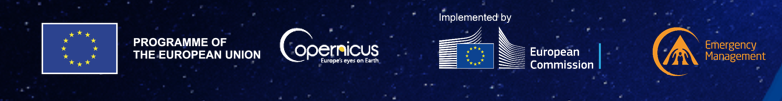
# Mapping discharge gauge station to glofas cell
## 4th CEMS Global Flood meeting, Interactive session 2: 
## Part 3 : Observations VS Simulations

#### Welcome to the companion Jupyter notebook of the 4th CEMS Global Flood meeting -  Interactive session 2 (part 3): Observations VS Simulations.
#### This notebook will walk you through how to:
* Map the station to the correct Glofas cell.
* Download glofas climatology of the corresponding cell.
* Visualize observed and analysis discharge data.
* Calculate and assess hydrological model performance metrics.
* Fit Gumbel distribution and calculate the thresholds.
* Visualize the thresholds and the hydrograph of the whole period.
* Read static data (flood thresholds and upstream area) .
* Compare and vizuialise station based thresholds against glofas thresholds .

#### Suppose you have discharge observations from multiple stations across your area of interest, and you want to compare historical model simulations against your measured data. This notebook will demonstrate how to perform this comparison step by step.
#### For more details please refer to the confluence page: https://confluence.ecmwf.int/display/CEMS/Mapping+locations+onto+CEMS-Flood+river+networks

#### To illustrate the process, we will use an observation station located in northern Morocco that is present in both GLOFAS and EFAS datasets. Below are the station metadata details:
* Station Name: Hajra Benkarrich
* River: Oued Elkbir
* Longitude: -5.447934
* Latitude: 35.514368
* Drainage Area: 498 km²
* Catchment: Coastal
* Continent: Africa
* Country Code: MAR
* Country Name: Morocco

## Further instructions
* Start a QGIS project to correctly map the station.
* Download the glofas_uparea.nc file (https://confluence.ecmwf.int/display/CEMS/Auxiliary+Data)
* In this notebook, we will only present the results. Please select a station of your choice and follow the instructions provided to perform the analysis step by step.


<div style="padding: 20px; background-color: #d4f1f7; border-left: 6px solid #4FC6E0; margin-bottom: 15px; width: 95%;">
    <strong>When mapping the station using the provider's coordinates, you may notice a slight discrepancy in position compared to GLOFAS coordinates. This difference occurs due to variations in spatial resolution between datasets.</strong>
</div>

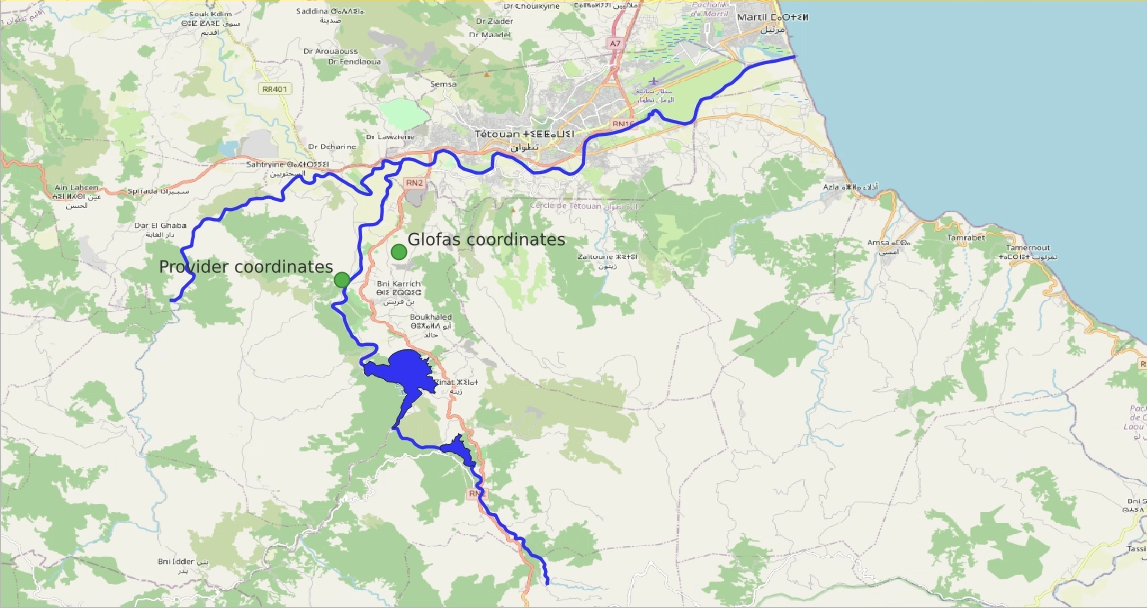

<div style="padding: 20px; background-color: #d4f1f7; border-left: 6px solid #4FC6E0; margin-bottom: 15px; width: 95%;">
    <strong>Import the uparea NetCDF file into QGIS and check if the station point falls within the same grid cell as the corresponding GLOFAS coordinates. </strong></div>

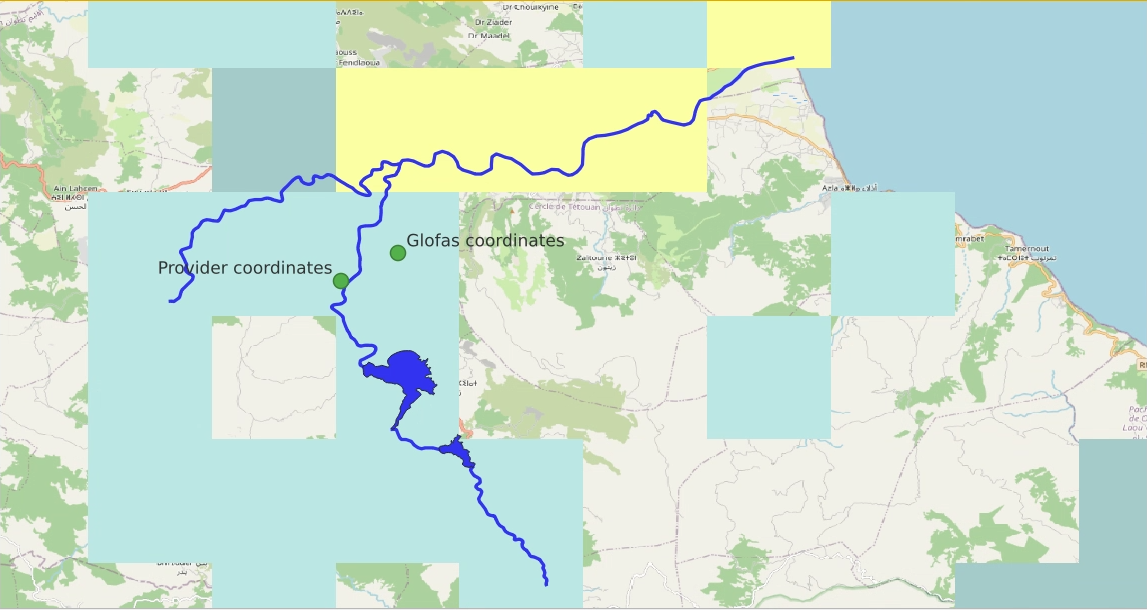

<div style="padding: 20px; background-color: #d4f1f7; border-left: 6px solid #4FC6E0; margin-bottom: 15px; width: 95%;">
    <strong>Ensure that the upstream area of the station, as provided by the data provider, closely matches the upstream area of the corresponding GLOFAS cell. </strong>
</div>

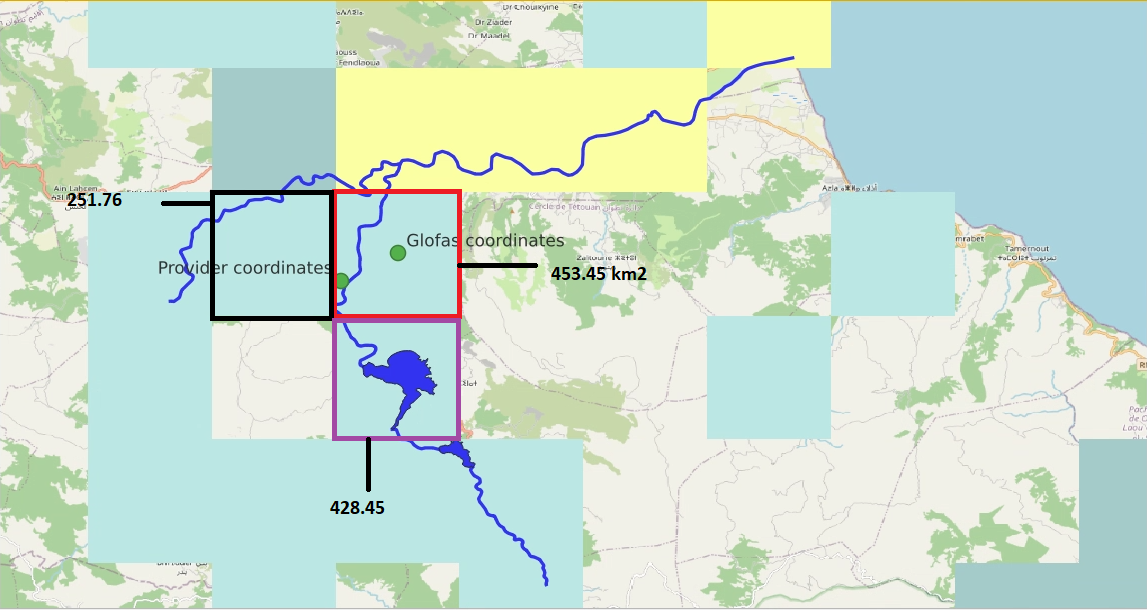

<div style="padding: 20px; background-color: #d4f1f7; border-left: 6px solid #4FC6E0; margin-bottom: 15px; width: 95%;">
    <strong>For more details about mapping stations , please see <a href=https://confluence.ecmwf.int/display/CEMS/Mapping+locations+onto+CEMS-Flood+river+networks>Mapping stations onto CEMS Flood River Network</a>  </strong>
</div>

In [1]:
import os
import glob
# CDS API
import cdsapi
from tqdm import tqdm

# Libraries for working with multidimensional arrays
import numpy as np
import xarray as xr
import pandas as pd

# Libraries for plotting and visualising data
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Disable warnings for data download via API
import urllib3 
urllib3.disable_warnings()
# Disable xarray runtime warnings
import warnings
warnings.simplefilter("ignore", category=RuntimeWarning)

#metrics
from scipy.stats import pearsonr
from scipy.stats import gumbel_r

In [2]:
# Create a folder to store downloaded Data
DATADIR = '/scratch/ecm3644/glofas-workshop/Salvador/Observations/'
os.makedirs(DATADIR, exist_ok=True)


## Download GloFAS climatology of the corresponding cell

In [3]:
## === Retrieve GloFAS Climatology ===

c = cdsapi.Client()

DATASET = 'cems-glofas-historical'
YEARS = ['%02d' % (mn) for mn in range(1990, 2025)]
MONTHS = ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']
DAYS = ['%02d' % (mn) for mn in range(1, 32)]

for year in tqdm(YEARS, desc="Downloading data", unit="year"):
    REQUEST = {
        'system_version': 'version_4_0',
        'product_type': 'consolidated',
        'hydrological_model': 'lisflood',
        'variable': 'river_discharge_in_the_last_24_hours',
        'hyear': year,
        'hmonth': MONTHS,
        'hday': DAYS,
        'data_format': "grib",
        "area": [35.72, -5.63, 35.37, -5.26],
        'download_format': "unarchived"
    }
    
    # Download file for the given year
    c.retrieve(DATASET, REQUEST).download(f'{DATADIR}{DATASET}_{year}.grib')

2025-03-27 13:06:36,052 INFO [2024-02-01T00:00:00] Please note we suggest checking the list of known issues on the GloFAS wiki
[here](https://confluence.ecmwf.int/display/CEMS/GloFAS+-+Known+Issues)
before downloading the dataset.
2025-03-27 13:06:36,053 WARNING [2025-03-27T13:06:36.046799] You are using a deprecated API endpoint. If you are using cdsapi, please upgrade to the latest version.
2025-03-27 13:06:36,053 INFO Request ID is fb46ff9d-5553-4f51-baf3-cdeb1d30ab1b
2025-03-27 13:06:36,088 INFO status has been updated to accepted


KeyboardInterrupt: 

In [4]:
#Read multiple glofas historical data grib files
grib_files = sorted(glob.glob(os.path.join('/scratch/ecm3644/glofas-workshop/Salvador/Observations/', "cems-glofas-historical_*.grib")))
glofas_data = xr.open_mfdataset(grib_files, engine="cfgrib", combine="by_coords")

#Read the observations csv file
Gauge_station = pd.read_csv('/perm/ecm3644/efas/efas-observations/Qobs_24.csv', parse_dates=['Timestamp'])

<div style="padding: 20px; background-color: #d4f1f7; border-left: 6px solid #4FC6E0; margin-bottom: 15px; width: 95%;">
    <strong>After mapping the station to the correct GLOFAS cell, we need to extract the coordinates of that cell in order to compare it with our time series. <br>
We assume that you’ve already completed this step and identified the coordinates of the cell that best represents the station.<br>
If you extract the coordinates of the GLOFAS cell from QGIS, the longitude will be in the range [-180, 180], whereas the GRIB files use longitudes in the range [0, 360]. Therefore, you need to add 360 to the longitude value if it's negative, to match the GRIB file convention.</strong>

In [5]:
Long=354.575 #(Long=lon+360)
lon=-5.425
Lat=35.525

In [6]:
# Convert xarray datarray timeseries to dataframe
Gauge_station['Timestamp'] = pd.to_datetime(Gauge_station['Timestamp'])

Timeserie = glofas_data.sel(latitude=Lat, longitude=Long, method='nearest')
Timeserie_dataframe = Timeserie[['time', 'dis24']].to_dataframe().reset_index()

In [7]:
# Convert xarray DataArray to DataFrame
glofas_timeseries = Timeserie_dataframe[['time', 'dis24']]
Gauge_station.rename(columns={"Timestamp": "time", "6954": "observational_discharge"}, inplace=True)
glofas_timeseries.rename(columns={"dis24": "glofas_discharge"}, inplace=True)
# Merge both datasets on the "time"
observed_vs_analysis = pd.merge(Gauge_station, glofas_timeseries, on="time", how="outer")

/etc/ecmwf/ssd/ssd1/jupyterhub/ecm3644-jupyterhub/tmpdirs/ecm3644.34610273/ipykernel_3457913/1674555776.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  glofas_timeseries.rename(columns={"dis24": "glofas_discharge"}, inplace=True)


[12.385 11.989 13.73  ...  4.8    4.798  4.75 ]
[ 9.296875  6.28125  77.71875  ...  0.15625   0.125     0.125   ]


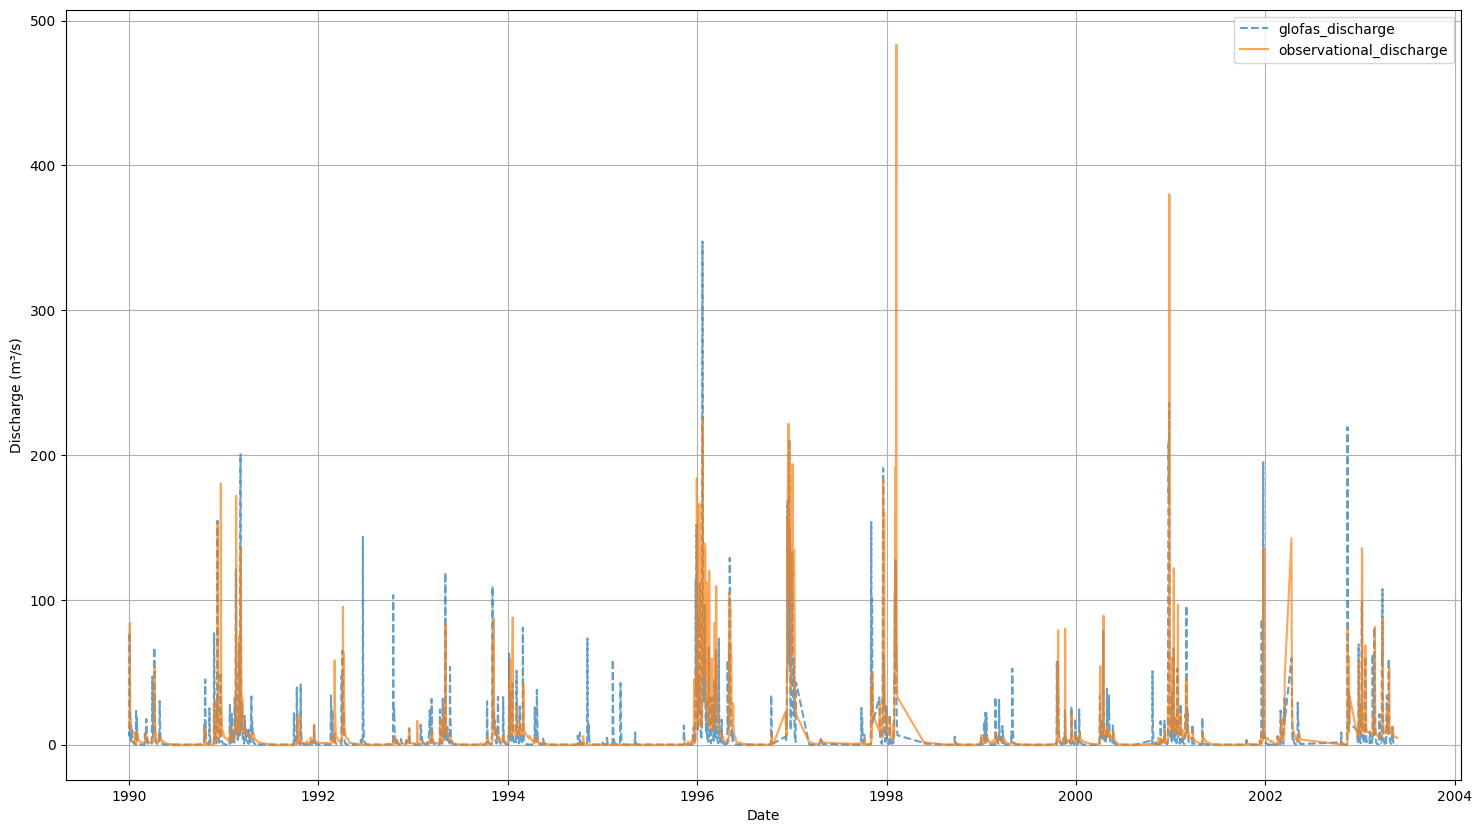

In [8]:
observed_vs_analysis = observed_vs_analysis.dropna(subset=['observational_discharge', 'glofas_discharge'])

# Extract observed and simulated values
obs = observed_vs_analysis['observational_discharge'].values
sim = observed_vs_analysis['glofas_discharge'].values
print(obs)
print(sim)

plt.figure(figsize=(18, 10))
plt.plot(observed_vs_analysis['time'], observed_vs_analysis['glofas_discharge'], label="glofas_discharge", linestyle="--", alpha=0.7)
plt.plot(observed_vs_analysis['time'], observed_vs_analysis['observational_discharge'], label="observational_discharge", linestyle="-", alpha=0.7)

plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.legend()
plt.grid(True)
plt.show()

* Visualize observed and analysis discharge data.
* Calculate and assess hydrological model performance metrics.


 Model Performance Metrics:
         KGE       NSE      Bias  Variability  Correlation
0  0.556809  0.263261  0.891554     0.934871     0.575246


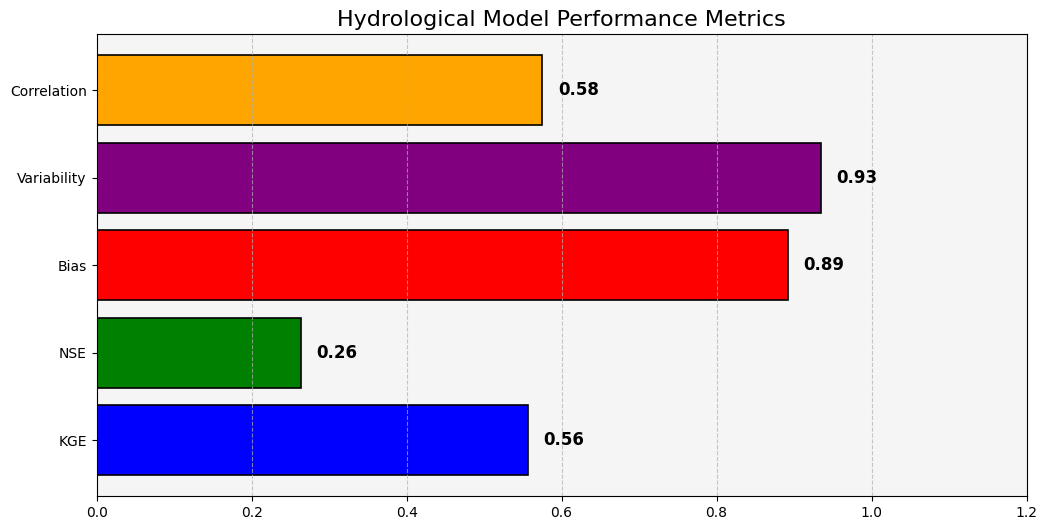

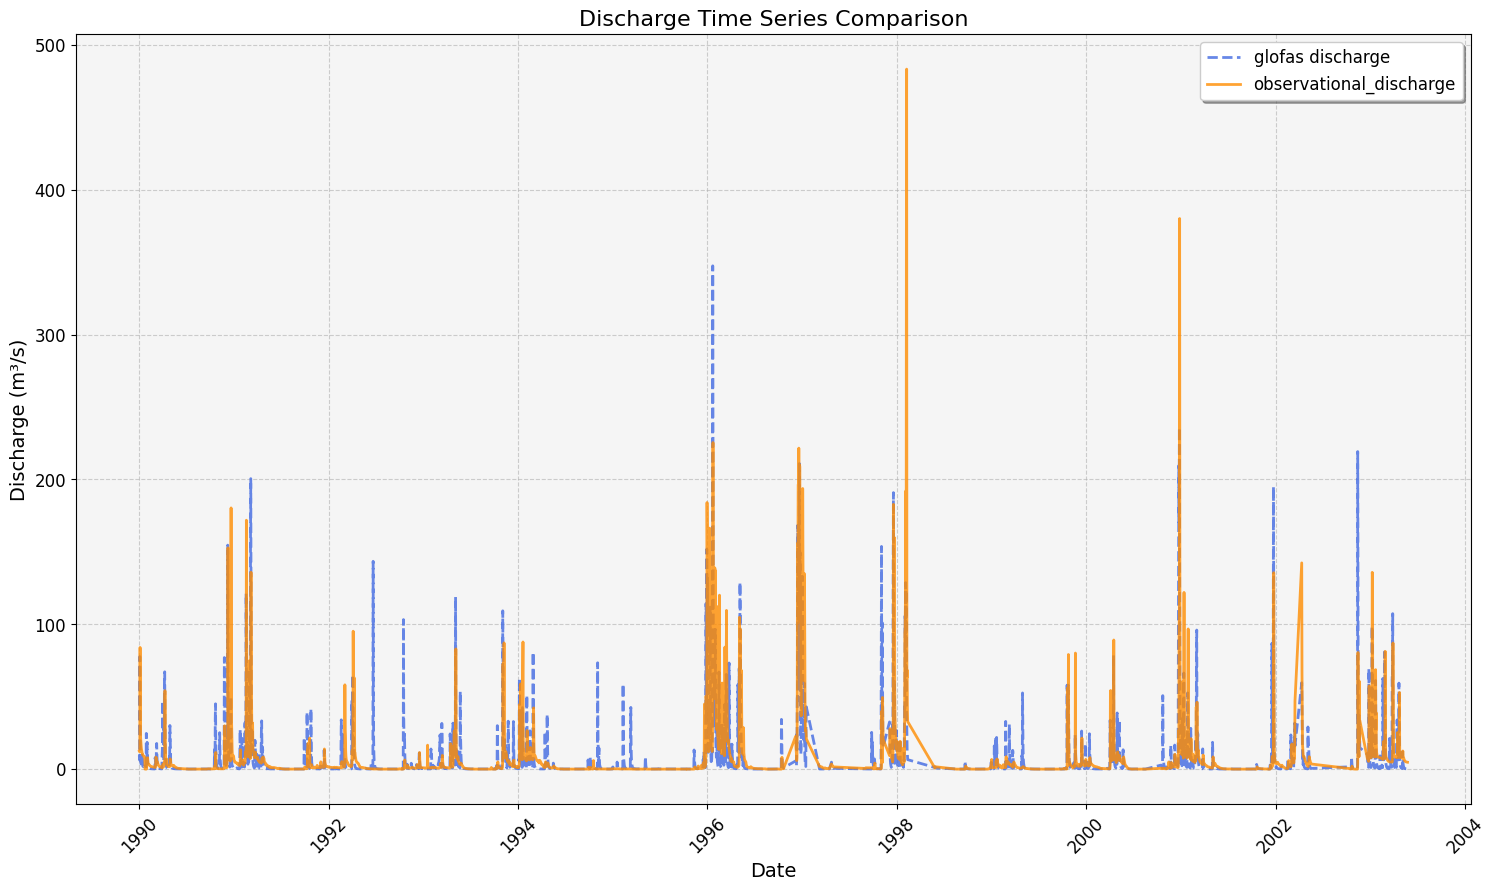

In [9]:
# Define and calculate performance metric functions
def kge(obs, sim):
    """ Modified KGE Gupta, H.V., Kling, H., Yilmaz, K.K. and Martinez, G.F. (2009) Decomposition of the Mean Squared Error and NSE Performance Criteria: Implications for Improving Hydrological Modelling. Journal of Hydrology, 377, 80-91."""
    """ https://www.sciencedirect.com/science/article/abs/pii/S0022169409004843?via%3Dihub """
    r = np.corrcoef(obs, sim)[0, 1]  # Correlation
    beta = np.mean(sim) / np.mean(obs)  # Bias
    gamma = (np.std(sim) / np.mean(sim)) / (np.std(obs) / np.mean(obs))  # Variability
    return 1 - np.sqrt((r - 1) ** 2 + (beta - 1) ** 2 + (gamma - 1) ** 2) #Modified KGE
    

def nse(obs, sim):
    """ """
    return 1 - (np.sum((obs - sim) ** 2) / np.sum((obs - np.mean(obs)) ** 2))

def bias(obs, sim):
    return np.mean(sim) / np.mean(obs)

def variability(obs, sim):
    return (np.std(sim) / np.mean(sim)) / (np.std(obs) / np.mean(obs))

# Compute performance metrics
performance_metrics = {
    "KGE": kge(obs, sim),
    "NSE": nse(obs, sim),
    "Bias": bias(obs, sim),
    "Variability": variability(obs, sim),
    "Correlation": pearsonr(obs, sim)[0]
}

# Convert to DataFrame
performance_df = pd.DataFrame(performance_metrics, index=[0])

print("\n Model Performance Metrics:\n", performance_df)

colors = ['blue', 'green', 'red', 'purple', 'orange']

plt.figure(figsize=(12, 6))
bars = plt.barh(list(performance_metrics.keys()), list(performance_metrics.values()), color=colors, edgecolor="black", linewidth=1.2)
plt.title("Hydrological Model Performance Metrics", fontsize=16)
plt.xlim(0, 1.2)  # Ensure values fit well in the chart
plt.grid(axis="x", linestyle="--", alpha=0.7)

for bar, value in zip(bars, performance_metrics.values()):
    plt.text(value + 0.02, bar.get_y() + bar.get_height()/2, f"{value:.2f}", va="center", fontsize=12, fontweight="bold")

# background color
plt.gca().set_facecolor('#f5f5f5')

plt.show()

# glofas Vs observational timeseries 

plt.figure(figsize=(18, 10))
plt.plot(observed_vs_analysis['time'], observed_vs_analysis['glofas_discharge'], label="glofas discharge", linestyle="--", linewidth=2, color="royalblue", alpha=0.8)
plt.plot(observed_vs_analysis['time'], observed_vs_analysis['observational_discharge'], label="observational_discharge", linestyle="-", linewidth=2, color="darkorange", alpha=0.8)

plt.xlabel("Date", fontsize=14)
plt.ylabel("Discharge (m³/s)", fontsize=14)
plt.title("Discharge Time Series Comparison", fontsize=16)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)

plt.grid(True, linestyle="--", alpha=0.6)

plt.gca().set_facecolor('#f5f5f5')

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.show()


## Fit Gumbel distribution and calculate the return period thresholds.
Visualize the thresholds and the hydrograph of the whole period.

 Extended Flood Thresholds (Gumbel):
                 Flood Thresholds
1.5-year Flood        132.517768
2-year Flood          164.007374
5-year Flood          241.502410
10-year Flood         292.810867
20-year Flood         342.027171
50-year Flood         405.732628
100-year Flood        453.470903
200-year Flood        501.034989
500-year Flood        563.786769


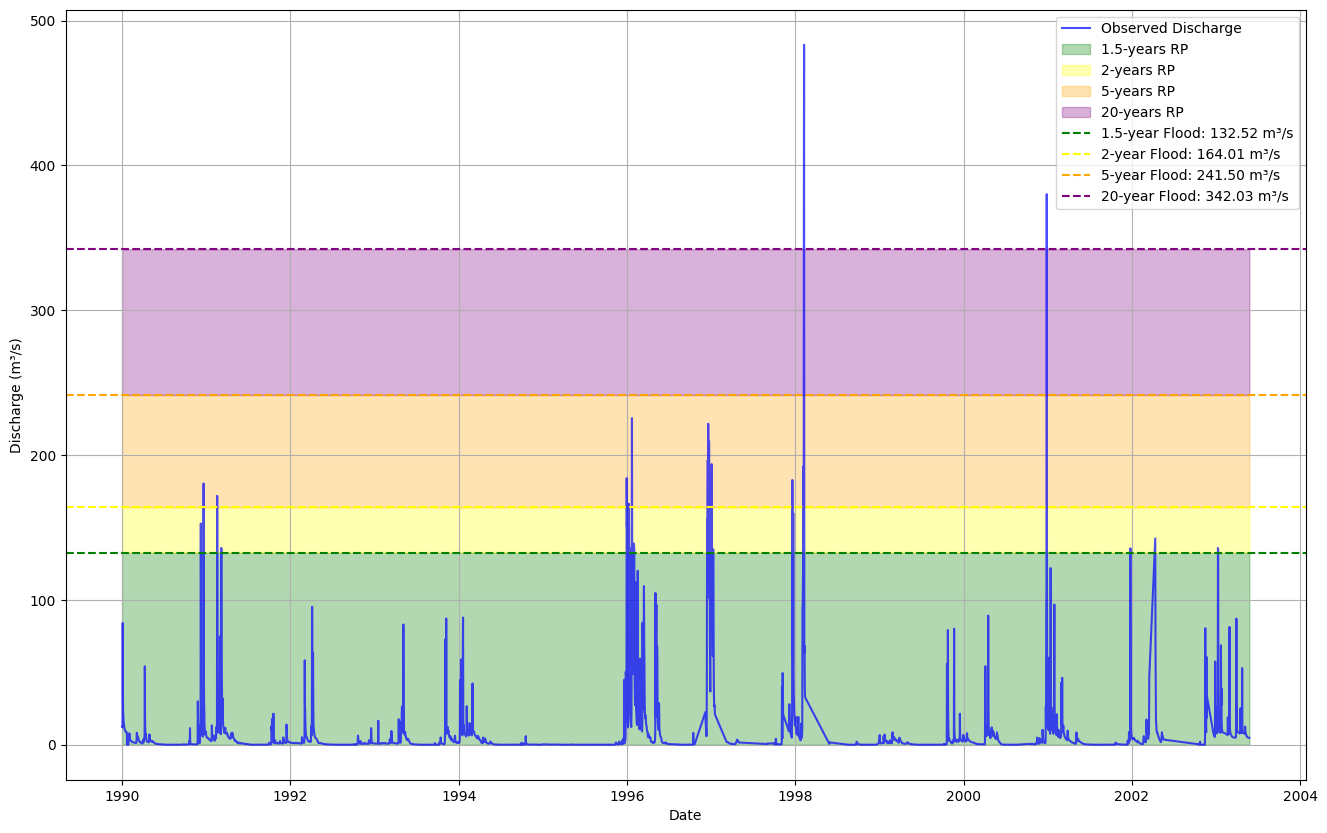

In [10]:
# extract the Annual Maximum Series
observed_vs_analysis['year'] = observed_vs_analysis['time'].dt.year
annual_max = observed_vs_analysis.groupby('year')['observational_discharge'].max().values

# Define return periods
extended_return_periods = [1.5,2, 5, 10, 20, 50, 100, 200, 500]

# Fit Gumbel Distribution
params_gumbel = gumbel_r.fit(annual_max)
gumbel_thresholds = {f"{rp}-year Flood": gumbel_r.ppf(1 - 1/rp, *params_gumbel) for rp in extended_return_periods}

# thresholds to DataFrame
threshold_df = pd.DataFrame(gumbel_thresholds, index=["Flood Thresholds"]).T
print(" Extended Flood Thresholds (Gumbel):\n", threshold_df)

# Pallette
colors = plt.cm.viridis(np.linspace(0, 1, len(extended_return_periods)))

# observed discharge with return period thresholds
plt.figure(figsize=(16, 10))
plt.plot(observed_vs_analysis['time'], observed_vs_analysis['observational_discharge'], label="Observed Discharge", color="blue", alpha=0.7)

#threshold values
threshold_1_5 = gumbel_thresholds['1.5-year Flood']
threshold_2 = gumbel_thresholds['2-year Flood']
threshold_5 = gumbel_thresholds['5-year Flood']
threshold_20 = gumbel_thresholds['20-year Flood']

# Fill areas between thresholds with different colors
plt.fill_between(observed_vs_analysis['time'], 0, threshold_1_5, color='green', alpha=0.3, label="1.5-years RP")
plt.fill_between(observed_vs_analysis['time'], threshold_1_5, threshold_2, color='yellow', alpha=0.3, label="2-years RP")
plt.fill_between(observed_vs_analysis['time'], threshold_2, threshold_5, color='orange', alpha=0.3, label="5-years RP")
plt.fill_between(observed_vs_analysis['time'], threshold_5, threshold_20, color='purple', alpha=0.3, label="20-years RP")
threshold_colors = {
    '1.5-year Flood': 'green',
    '2-year Flood':   'yellow',
    '5-year Flood':   'orange',
    '20-year Flood':  'purple',
}
for i, (label, value) in enumerate(gumbel_thresholds.items()):
    if label in ['1.5-year Flood','2-year Flood', '5-year Flood', '20-year Flood']:
        plt.axhline(y=value, linestyle="--", color=threshold_colors[label], label=f"{label}: {value:.2f} m³/s")

plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.legend()
plt.grid(True)
plt.show()

### Read GloFAS threshold files .

In [11]:
thresholds_1_5=xr.open_dataset('/perm/ecm3644/glofas/Static_maps/flood_threshold_glofas_v4_rl_1.5.nc')
thresholds_2=xr.open_dataset('/perm/ecm3644/glofas/Static_maps/flood_threshold_glofas_v4_rl_2.0.nc')
thresholds_5=xr.open_dataset('/perm/ecm3644/glofas/Static_maps/flood_threshold_glofas_v4_rl_5.0.nc')
thresholds_10=xr.open_dataset('/perm/ecm3644/glofas/Static_maps/flood_threshold_glofas_v4_rl_10.0.nc')
thresholds_20=xr.open_dataset('/perm/ecm3644/glofas/Static_maps/flood_threshold_glofas_v4_rl_20.0.nc')
thresholds_50=xr.open_dataset('/perm/ecm3644/glofas/Static_maps/flood_threshold_glofas_v4_rl_50.0.nc')
thresholds_100=xr.open_dataset('/perm/ecm3644/glofas/Static_maps/flood_threshold_glofas_v4_rl_100.0.nc')
thresholds_200=xr.open_dataset('/perm/ecm3644/glofas/Static_maps/flood_threshold_glofas_v4_rl_200.0.nc')
thresholds_500=xr.open_dataset('/perm/ecm3644/glofas/Static_maps/flood_threshold_glofas_v4_rl_500.0.nc')
print(thresholds_1_5.data_vars,thresholds_2.data_vars,thresholds_5.data_vars,thresholds_10.data_vars,thresholds_20.data_vars,thresholds_50.data_vars,thresholds_100.data_vars,thresholds_200.data_vars,thresholds_500.data_vars)

Data variables:
    rl_1.5   (lat, lon) float64 173MB ... Data variables:
    rl_2.0   (lat, lon) float64 173MB ... Data variables:
    rl_5.0   (lat, lon) float64 173MB ... Data variables:
    rl_10.0  (lat, lon) float64 173MB ... Data variables:
    rl_20.0  (lat, lon) float64 173MB ... Data variables:
    rl_50.0  (lat, lon) float64 173MB ... Data variables:
    rl_100.0  (lat, lon) float64 173MB ... Data variables:
    rl_200.0  (lat, lon) float64 173MB ... Data variables:
    rl_500.0  (lat, lon) float64 173MB ...


## Compare observational thresholds against GloFAS thresholds

{'2-year Flood': 144.10539621498776, '5-year Flood': 203.69808226893315, '10-year Flood': 243.15362576735413, '20-year Flood': 281.00033036137705, '50-year Flood': 329.9890073622495, '100-year Flood': 366.69912702507384, '200-year Flood': 403.27529762771024, '500-year Flood': 451.53060948024796}

Comparison of Observed vs. GloFAS Flood Thresholds:

                Observed (Gauge)  GloFAS (Simulated)
2-year Flood          164.007374          144.105396
5-year Flood          241.502410          203.698082
10-year Flood         292.810867          243.153626
20-year Flood         342.027171          281.000330
50-year Flood         405.732628          329.989007
100-year Flood        453.470903          366.699127
200-year Flood        501.034989          403.275298
500-year Flood        563.786769          451.530609


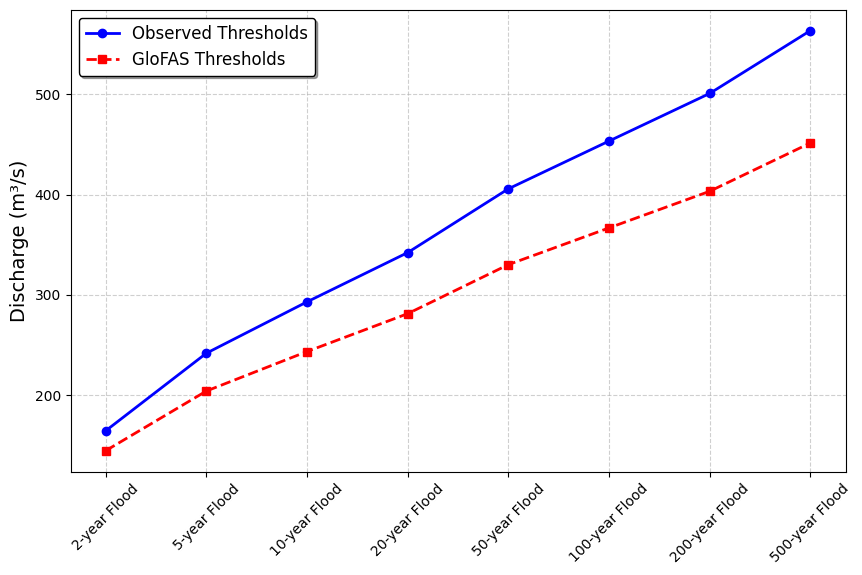

In [12]:
# Observed flood thresholds from the previous code snipet
observed_thresholds = threshold_df["Flood Thresholds"].to_dict()

# GLOFAS thresholds from the NetCDF datasets at the station's location
glofas_thresholds = {
    "2-year Flood": thresholds_2["rl_2.0"].sel(lat=Lat, lon=lon, method="nearest").values.item(),
    "5-year Flood": thresholds_5["rl_5.0"].sel(lat=Lat, lon=lon, method="nearest").values.item(),
    "10-year Flood": thresholds_10["rl_10.0"].sel(lat=Lat, lon=lon, method="nearest").values.item(),
    "20-year Flood": thresholds_20["rl_20.0"].sel(lat=Lat, lon=lon, method="nearest").values.item(),
    "50-year Flood": thresholds_50["rl_50.0"].sel(lat=Lat, lon=lon, method="nearest").values.item(),
    "100-year Flood": thresholds_100["rl_100.0"].sel(lat=Lat, lon=lon, method="nearest").values.item(),
    "200-year Flood": thresholds_200["rl_200.0"].sel(lat=Lat, lon=lon, method="nearest").values.item(),
    "500-year Flood": thresholds_500["rl_500.0"].sel(lat=Lat, lon=lon, method="nearest").values.item()
}
print(glofas_thresholds)
# Convert to DataFrame
comparison_df = pd.DataFrame({
    "Observed (Gauge)": observed_thresholds,
    "GloFAS (Simulated)": list(glofas_thresholds.values())
}, index=glofas_thresholds.keys())

print("\nComparison of Observed vs. GloFAS Flood Thresholds:\n")
print(comparison_df)

# Observed vs. GLOFAS Thresholds
plt.figure(figsize=(10, 6))
plt.plot(comparison_df.index, comparison_df["Observed (Gauge)"], marker="o", linestyle="-", label="Observed Thresholds", color="blue", linewidth=2)
plt.plot(comparison_df.index, comparison_df["GloFAS (Simulated)"], marker="s", linestyle="--", label="GloFAS Thresholds", color="red", linewidth=2)

plt.ylabel("Discharge (m³/s)", fontsize=14)
plt.xticks(rotation=45)  # Rotate x-axis labels to 45 degrees
plt.legend(fontsize=12, loc="upper left", frameon=True, shadow=True, edgecolor="black")
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()
